# 🦋 Klasifikasi Kupu-Kupu Beracun Menggunakan Gabungan Fitur GLCM, HSV Stats, & HSV Color Histogram dengan KNN
---
## Pengolahan Citra Digital - Kelompok 9

Notebook ini berisi implementasi ekstraksi fitur **Gray-Level Co-occurrence Matrix (GLCM)**, **Statistik Global HSV**, serta **Color Histogram (Hue & Saturation)**, diikuti oleh klasifikasi menggunakan algoritma **K-Nearest Neighbors (KNN)** pada dataset baru di folder **`data_citra`** (yang memiliki struktur split `train`, `valid`, dan `test`).

### Alur Kerja (Workflow):
1. **Definisi Ground Truth**: Mengelompokkan spesies kupu-kupu menjadi kelas **Beracun (1)** dan **Tidak Beracun (0)** berdasarkan folder nama spesies di `data_citra`.
2. **Pemuatan Dataset**: Membaca gambar dari folder `data_citra/` untuk partisi *train*, *valid*, dan *test*.
3. **Ekstraksi Fitur Gabungan**:
   - **Tekstur GLCM**: Menghasilkan 24 fitur (6 properti $\times$ 4 sudut arah $\times$ 1 jarak piksel).
   - **Statistik Global HSV**: Menghasilkan 6 fitur (Rata-rata dan Standar Deviasi dari kanal Hue, Saturation, dan Value).
   - **Histogram Warna HSV**: Menghasilkan 16 fitur (1D Histogram Hue dengan 8 bin dan 1D Histogram Saturation dengan 8 bin).
   - Total fitur per citra = $24 + 6 + 16 = 46$ fitur.
4. **Normalisasi Fitur**: Menggunakan `StandardScaler` agar setiap fitur memiliki rentang nilai yang setara sebelum masuk ke KNN.
5. **Penyeimbangan Kelas Menggunakan SMOTE**: Menggunakan SMOTE dengan `sampling_strategy=0.40` untuk menyeimbangkan kelas pada data latihan secara optimal, meningkatkan sensitivitas terhadap kelas Beracun tanpa menghasilkan terlalu banyak False Positive.
6. **Hyperparameter Tuning KNN**: Mencari nilai $K$ terbaik dan tipe bobot (`uniform` vs `distance`) menggunakan cross-validation pada data Validation dengan threshold keputusan standar (0.50).
7. **Evaluasi Akhir**: Menguji model KNN terbaik pada data Test dengan threshold standar (0.50) dan menampilkan Confusion Matrix tunggal, Classification Report, Kurva ROC-AUC, serta visualisasi sampel hasil prediksi.

In [68]:
import os
import random
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from skimage.feature import graycomatrix, graycoprops
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, f1_score
from imblearn.over_sampling import SMOTE

# Menonaktifkan peringatan
warnings.filterwarnings('ignore')

# Set seed
np.random.seed(42)
random.seed(42)

print("Seluruh library berhasil dimuat!")

Seluruh library berhasil dimuat!


In [69]:
# Definisi Spesies Beracun (Ground Truth) berdasarkan referensi biologi
TOXIC_SPECIES = {
    'MONARCH',             # toksin glikosida jantung dari tanaman milkweed
    'ATALA',               # toksin cycasin dari cycad
    'PIPEVINE SWALLOW',    # asam aristolochic dari pipevine
    'BLUE SPOTTED CROW',   # toksin dari tanaman inang
    'GREAT EGGFLY',        # mimetik spesies beracun
    'DANAID EGGFLY',       # mimetik Monarch
    'VICEROY',             # mimikri Batesian terhadap Monarch
    'JULIA',               # Heliconius grup — toksik ringan
    'MALACHITE',           # zat kimia defensif berbau pekat
    'RED CRACKER',         # pola warna peringatan (aposematism)
    'CAIRNS BIRDWING',     # toksin ringan
    'ZEBRA LONG WING',     # toksin dari mengonsumsi serbuk sari
    'RED POSTMAN',         # cyanogenic glycoside
    'STRAITED QUEEN',      # kerabat Monarch dengan toksin serupa
    'SIXSPOT BURNET MOTH', # sangat beracun — mengandung sianida
    'CINNABAR MOTH',       # alkaloid pyrrolizidine
    'GARDEN TIGER MOTH',   # pertahanan toksin tanaman inang
    'ROSY MAPLE MOTH',     # warna peringatan kuat kuning-merah jambu
    'IO MOTH',             # duri (spine) beracun saat larva
    'BANDED TIGER MOTH',   # alkaloid defensif pahit
}

print(f"Total spesies beracun yang didefinisikan: {len(TOXIC_SPECIES)}")

Total spesies beracun yang didefinisikan: 20


## Sel 4 — Pemuatan Dataset dan Ekstraksi Fitur Gabungan + Histogram

Fungsi di bawah ini mengekstrak fitur gabungan dari gambar di `data_citra/`:
1. **Grayscale (GLCM)**: 24 fitur tekstur.
2. **Color Stats (HSV)**: 6 fitur statistik global.
3. **Color Histogram (HSV)**: 16 fitur distribusi warna (8 bin Hue + 8 bin Saturation).

Total kombinasi fitur per gambar = 46 fitur.

**Caching:** Ekstraksi fitur akan disimpan ke file CSV di folder `output_csv/` dengan nama prefiks `glcm_color_hist_dc_` untuk mempercepat pemuatan ulang.

In [70]:
BASE_DIR = Path('./data_citra')
TRAIN_DIR = BASE_DIR / 'train'
VALID_DIR = BASE_DIR / 'valid'
TEST_DIR = BASE_DIR / 'test'

CACHE_DIR = Path('output_csv')
CACHE_DIR.mkdir(exist_ok=True)

def extract_combined_features(filepath):
    # Grayscale for GLCM
    img_gray = cv2.imread(str(filepath), cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        return None
    img_gray_res = cv2.resize(img_gray, (128, 128))
    
    glcm = graycomatrix(img_gray_res, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], 
                        levels=256, symmetric=True, normed=True)
    properties = ['contrast', 'correlation', 'energy', 'homogeneity', 'ASM', 'dissimilarity']
    glcm_features = []
    for prop in properties:
        glcm_features.extend(graycoprops(glcm, prop).flatten())
        
    # Color for HSV
    img_bgr = cv2.imread(str(filepath))
    if img_bgr is None:
        return None
    img_bgr_res = cv2.resize(img_bgr, (128, 128))
    img_hsv = cv2.cvtColor(img_bgr_res, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(img_hsv)
    
    # 1. Global color statistics (6 features)
    color_stats = [
        h.mean(), h.std(),
        s.mean(), s.std(),
        v.mean(), v.std()
    ]
    
    # 2. Hue & Saturation 1D Histograms (8 bins each, normalized)
    hist_h = cv2.calcHist([img_hsv], [0], None, [8], [0, 180])
    hist_s = cv2.calcHist([img_hsv], [1], None, [8], [0, 256])
    
    cv2.normalize(hist_h, hist_h, 0, 1, cv2.NORM_MINMAX)
    cv2.normalize(hist_s, hist_s, 0, 1, cv2.NORM_MINMAX)
    
    color_hist = list(hist_h.flatten()) + list(hist_s.flatten())
    
    return glcm_features + color_stats + color_hist

def load_and_extract_split(split_dir, cache_csv):
    if os.path.exists(cache_csv):
        print(f"[{split_dir.name.upper()}] Memuat fitur Gabungan + Histogram dari cache CSV: {cache_csv}")
        df_cache = pd.read_csv(cache_csv)
        y = df_cache['label'].values
        filepaths = df_cache['filepath'].tolist()
        species = df_cache['species'].tolist()
        feat_cols = [c for c in df_cache.columns if c.startswith('feat_')]
        X = df_cache[feat_cols].values
        return X, y, filepaths, species
        
    features_list = []
    labels_list = []
    filepaths_list = []
    species_list = []
    
    subdirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])
    
    print(f"[{split_dir.name.upper()}] Memproses dan mengekstrak fitur Gabungan + Histogram dari folder...")
    for sp_dir in tqdm(subdirs):
        species_name = sp_dir.name.upper()
        label = 1 if species_name in TOXIC_SPECIES else 0
        
        for img_path in sp_dir.glob('*.*'):
            if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                feats = extract_combined_features(img_path)
                if feats is not None:
                    features_list.append(feats)
                    labels_list.append(label)
                    filepaths_list.append(str(img_path))
                    species_list.append(sp_dir.name)
                    
    X = np.array(features_list)
    y = np.array(labels_list)
    
    df_to_cache = pd.DataFrame(X, columns=[f'feat_{i}' for i in range(X.shape[1])])
    df_to_cache['label'] = y
    df_to_cache['filepath'] = filepaths_list
    df_to_cache['species'] = species_list
    df_to_cache.to_csv(cache_csv, index=False)
    print(f"[{split_dir.name.upper()}] Ekstraksi selesai dan disimpan ke cache CSV: {cache_csv}")
    
    return X, y, filepaths_list, species_list

# Ekstraksi fitur untuk Train, Valid, dan Test splits
X_train, y_train, train_paths, train_species = load_and_extract_split(TRAIN_DIR, CACHE_DIR / 'glcm_color_hist_dc_train.csv')
X_val, y_val, val_paths, val_species = load_and_extract_split(VALID_DIR, CACHE_DIR / 'glcm_color_hist_dc_valid.csv')
X_test, y_test, test_paths, test_species = load_and_extract_split(TEST_DIR, CACHE_DIR / 'glcm_color_hist_dc_test.csv')

print(f"\n[INFO] Ukuran Data Train : {X_train.shape} | Beracun: {np.sum(y_train)} | Aman: {len(y_train) - np.sum(y_train)}")
print(f"[INFO] Ukuran Data Valid : {X_val.shape} | Beracun: {np.sum(y_val)} | Aman: {len(y_val) - np.sum(y_val)}")
print(f"[INFO] Ukuran Data Test  : {X_test.shape} | Beracun: {np.sum(y_test)} | Aman: {len(y_test) - np.sum(y_test)}")

[TRAIN] Memuat fitur Gabungan + Histogram dari cache CSV: output_csv\glcm_color_hist_dc_train.csv
[VALID] Memuat fitur Gabungan + Histogram dari cache CSV: output_csv\glcm_color_hist_dc_valid.csv
[TEST] Memuat fitur Gabungan + Histogram dari cache CSV: output_csv\glcm_color_hist_dc_test.csv

[INFO] Ukuran Data Train : (1967, 46) | Beracun: 527 | Aman: 1440
[INFO] Ukuran Data Valid : (75, 46) | Beracun: 20 | Aman: 55
[INFO] Ukuran Data Test  : (75, 46) | Beracun: 20 | Aman: 55


## Sel 6 — Normalisasi Fitur menggunakan StandardScaler

Standardisasi fitur gabungan menggunakan `StandardScaler` agar setiap fitur memiliki pengaruh yang seimbang pada pencarian jarak KNN.

In [71]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Standardisasi fitur gabungan selesai!")

Standardisasi fitur gabungan selesai!


## Sel 8 — Tuning Nilai K dan Bobot Terbaik pada Validation Set dengan SMOTE

Mengevaluasi KNN untuk berbagai nilai $K \in \{1, 3, 5, 7, 9, 11, 13, 15\}$ dan tipe bobot (`uniform` vs `distance`) setelah menyeimbangkan kelas menggunakan SMOTE dengan `sampling_strategy=0.40` pada data latihan. Hal ini memungkinkan pencarian tetangga terdekat secara alami menggunakan threshold standar (0.50) dengan tingkat deteksi True Positive (Beracun) dan True Negative (Aman) yang seimbang dan optimal.

[INFO] Ukuran Data Train Sebelum SMOTE: (1967, 46) | Beracun: 527
[INFO] Ukuran Data Train Setelah SMOTE: (2016, 46) | Beracun: 576

Mulai proses Tuning Hyperparameter K dan Tipe Bobot...
K =  1 | Bobot: uniform  | Macro F1 (Val): 0.6362
K =  1 | Bobot: distance | Macro F1 (Val): 0.6362
K =  3 | Bobot: uniform  | Macro F1 (Val): 0.6708
K =  3 | Bobot: distance | Macro F1 (Val): 0.6708
K =  5 | Bobot: uniform  | Macro F1 (Val): 0.6362
K =  5 | Bobot: distance | Macro F1 (Val): 0.6591
K =  7 | Bobot: uniform  | Macro F1 (Val): 0.6250
K =  7 | Bobot: distance | Macro F1 (Val): 0.6476
K =  9 | Bobot: uniform  | Macro F1 (Val): 0.6591
K =  9 | Bobot: distance | Macro F1 (Val): 0.6708
K = 11 | Bobot: uniform  | Macro F1 (Val): 0.6711
K = 11 | Bobot: distance | Macro F1 (Val): 0.6832
K = 13 | Bobot: uniform  | Macro F1 (Val): 0.6711
K = 13 | Bobot: distance | Macro F1 (Val): 0.6711
K = 15 | Bobot: uniform  | Macro F1 (Val): 0.6957
K = 15 | Bobot: distance | Macro F1 (Val): 0.6957


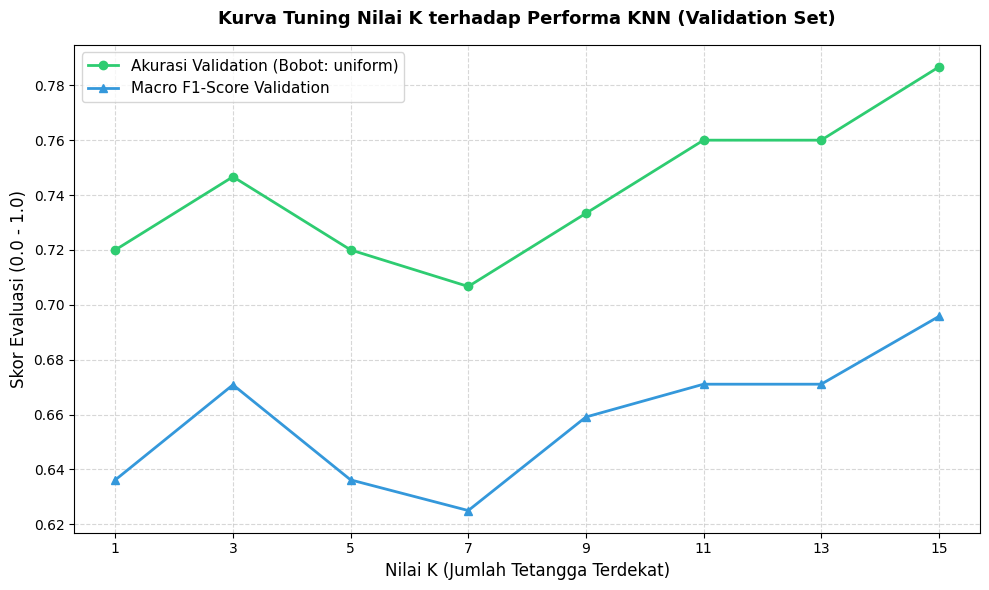


[HASIL TUNING]
K terbaik: 15
Bobot terbaik: uniform
Macro F1-Score terbaik pada Validation: 0.6957


In [72]:
# Menerapkan SMOTE dengan sampling_strategy=0.40 pada data latihan
smote = SMOTE(sampling_strategy=0.40, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"[INFO] Ukuran Data Train Sebelum SMOTE: {X_train_scaled.shape} | Beracun: {np.sum(y_train)}")
print(f"[INFO] Ukuran Data Train Setelah SMOTE: {X_train_res.shape} | Beracun: {np.sum(y_train_res)}")

k_values = [1, 3, 5, 7, 9, 11, 13, 15]
best_macro_f1 = -1
best_k = 5
best_weights = 'uniform'

print("\nMulai proses Tuning Hyperparameter K dan Tipe Bobot...")
for k in k_values:
    for weights in ['uniform', 'distance']:
        knn = KNeighborsClassifier(n_neighbors=k, weights=weights)
        knn.fit(X_train_res, y_train_res)
        y_val_pred = knn.predict(X_val_scaled)
        
        val_macro_f1 = f1_score(y_val, y_val_pred, average='macro', zero_division=0)
        print(f"K = {k:2d} | Bobot: {weights:8s} | Macro F1 (Val): {val_macro_f1:.4f}")
        
        if val_macro_f1 > best_macro_f1:
            best_macro_f1 = val_macro_f1
            best_k = k
            best_weights = weights

# Visualisasi kurva tuning K
val_accuracies = []
val_macro_f1s = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights=best_weights)
    knn.fit(X_train_res, y_train_res)
    y_val_pred = knn.predict(X_val_scaled)
    
    acc = accuracy_score(y_val, y_val_pred)
    val_accuracies.append(acc)
    val_macro_f1s.append(f1_score(y_val, y_val_pred, average='macro', zero_division=0))

plt.figure(figsize=(10, 6))
plt.plot(k_values, val_accuracies, marker='o', label=f'Akurasi Validation (Bobot: {best_weights})', color='#2ecc71', linewidth=2)
plt.plot(k_values, val_macro_f1s, marker='^', label='Macro F1-Score Validation', color='#3498db', linewidth=2)
plt.title('Kurva Tuning Nilai K terhadap Performa KNN (Validation Set)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Nilai K (Jumlah Tetangga Terdekat)', fontsize=12)
plt.ylabel('Skor Evaluasi (0.0 - 1.0)', fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n[HASIL TUNING]")
print(f"K terbaik: {best_k}")
print(f"Bobot terbaik: {best_weights}")
print(f"Macro F1-Score terbaik pada Validation: {best_macro_f1:.4f}")

## Sel 10 — Evaluasi Model KNN Terbaik pada Data Test dengan Threshold Standar (0.50)

Menguji model KNN terbaik hasil tuning pada data Test menggunakan threshold keputusan standar (0.50). Menampilkan Classification Report, Confusion Matrix Heatmap tunggal (tanpa threshold), dan Kurva ROC-AUC.

================ CLASSIFICATION REPORT (DATA TEST) ================
                      precision    recall  f1-score   support

Tidak Beracun (Aman)       0.77      0.87      0.82        55
    Beracun (Bahaya)       0.46      0.30      0.36        20

            accuracy                           0.72        75
           macro avg       0.62      0.59      0.59        75
        weighted avg       0.69      0.72      0.70        75



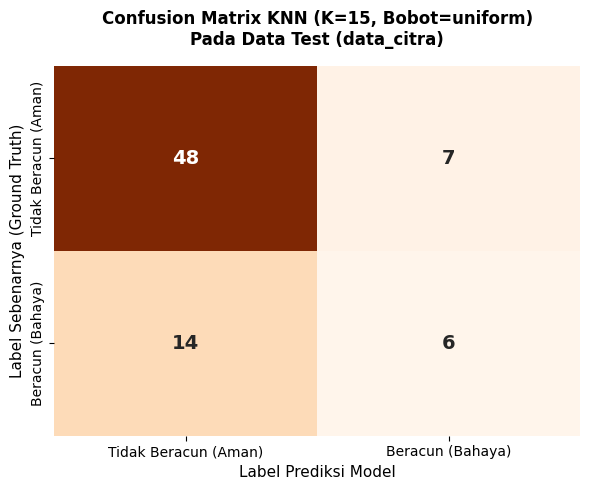

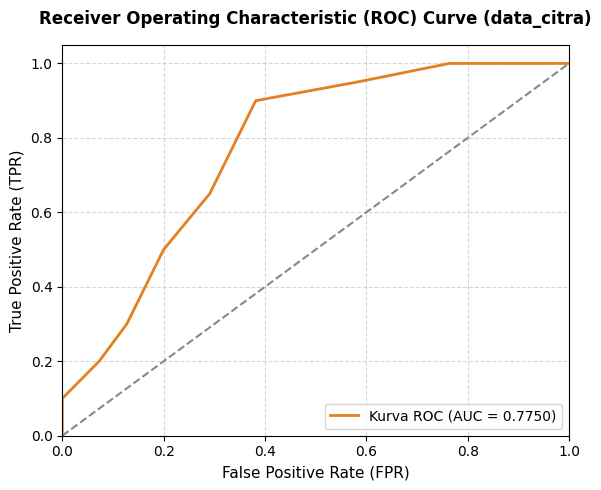

In [ ]:
best_knn = KNeighborsClassifier(n_neighbors=best_k, weights=best_weights)
best_knn.fit(X_train_res, y_train_res)

# Prediksi pada Test Set menggunakan default threshold 0.50
y_test_pred = best_knn.predict(X_test_scaled)
y_test_proba = best_knn.predict_proba(X_test_scaled)[:, 1]

# 1. Cetak classification report
print("================ CLASSIFICATION REPORT (DATA TEST) ================")
print(classification_report(y_test, y_test_pred, target_names=['Tidak Beracun (Aman)', 'Beracun (Bahaya)'], zero_division=0))

# 2. Visualisasi Confusion Matrix Heatmap Tunggal
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Tidak Beracun (Aman)', 'Beracun (Bahaya)'],
            yticklabels=['Tidak Beracun (Aman)', 'Beracun (Bahaya)'],
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
plt.title(f'Confusion Matrix KNN (K={best_k}, Bobot={best_weights})\nPada Data Test (data_citra)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Label Prediksi Model', fontsize=11)
plt.ylabel('Label Sebenarnya (Ground Truth)', fontsize=11)
plt.tight_layout()
plt.show()

# 3. Visualisasi Kurva ROC
if len(np.unique(y_test)) > 1:
    fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='#e67e22', lw=2, label=f'Kurva ROC (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='#7f8c8d', lw=1.5, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=11)
    plt.ylabel('True Positive Rate (TPR)', fontsize=11)
    plt.title('Receiver Operating Characteristic (ROC) Curve (data_citra)', fontsize=12, fontweight='bold', pad=15)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

## Sel 12 — Visualisasi Contoh Prediksi Citra Kupu-Kupu

Berikut visualisasi acak beberapa sampel gambar pada data Test beserta prediksi KNN:
- Judul **HIJAU**: Klasifikasi BENAR.
- Judul **MERAH**: Klasifikasi SALAH.

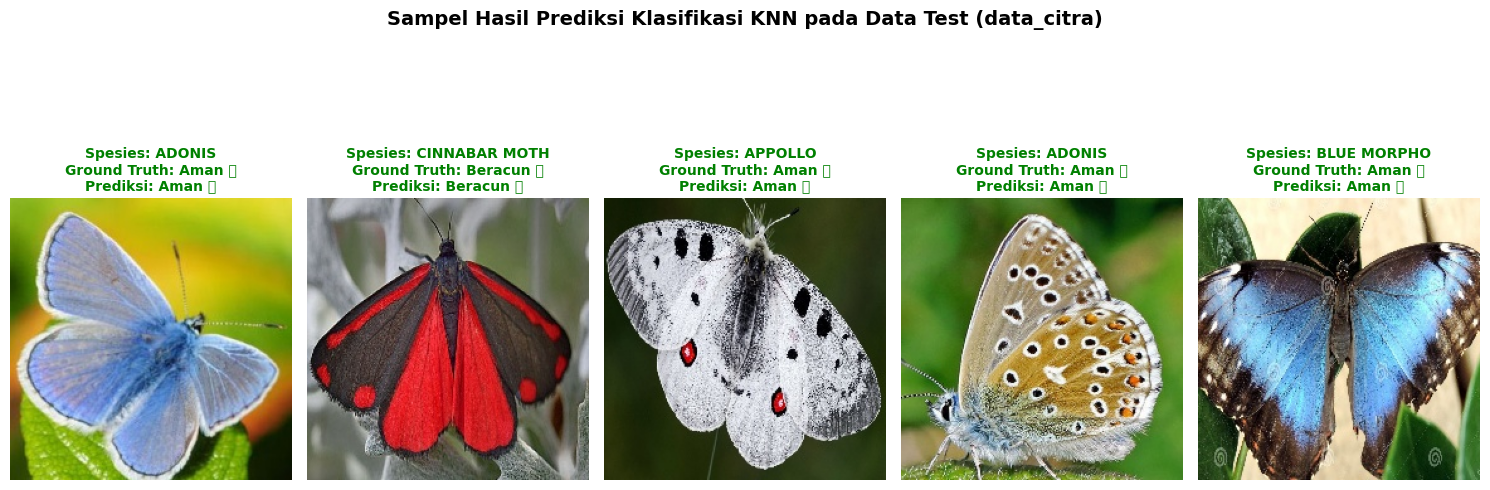

In [74]:
# Ambil gambar acak dari data Test untuk visualisasi
np.random.seed(42)
num_samples = min(5, len(test_paths))
if num_samples > 0:
    sample_indices = np.random.choice(len(test_paths), num_samples, replace=False)

    plt.figure(figsize=(15, 6))

    for i, idx in enumerate(sample_indices):
        img_path = test_paths[idx]
        true_label = y_test[idx]
        pred_label = y_test_pred[idx]
        species = test_species[idx]
        
        # Load RGB image
        img_bgr = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        title_color = 'green' if true_label == pred_label else 'red'
        true_str = 'Beracun 💀' if true_label == 1 else 'Aman 🌿'
        pred_str = 'Beracun 💀' if pred_label == 1 else 'Aman 🌿'
        
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img_rgb)
        plt.title(f"Spesies: {species}\nGround Truth: {true_str}\nPrediksi: {pred_str}", 
                  color=title_color, fontsize=10, fontweight='bold')
        plt.axis('off')

    plt.suptitle("Sampel Hasil Prediksi Klasifikasi KNN pada Data Test (data_citra)", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()